# Pablo Salvagni

### Parte 1 (imágenes en /white_patch):
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de 
White patch.

In [10]:
#Packetes utilizados
%matplotlib inline
# %matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [11]:
# Function to apply white_patch in all images.
def apply_white_patch(img, percentile=95):
    """
    The White Patch algorithm is applied to balance the whites.
    The 95 percentile is used to prevent white noise from misleading the algorithm.
    """
    # 1 - Separete channesls
    b, g, r = cv.split(img)

    # 2 - Calculate the reference value in each channel using the defined percentil
    val_b = np.percentile(b, percentile)
    val_g = np.percentile(g, percentile)
    val_r = np.percentile(r, percentile)

    # 3 - Calculate the scaling factors and apply the correction.
    out_b = np.clip(b * (255.0 / val_b), 0, 255).astype(np.uint8)
    out_g = np.clip(g * (255.0 / val_g), 0, 255).astype(np.uint8)
    out_r = np.clip(r * (255.0 / val_r), 0, 255).astype(np.uint8)

    # 4. Join the corrected channels
    return cv.merge([out_b, out_g, out_r])


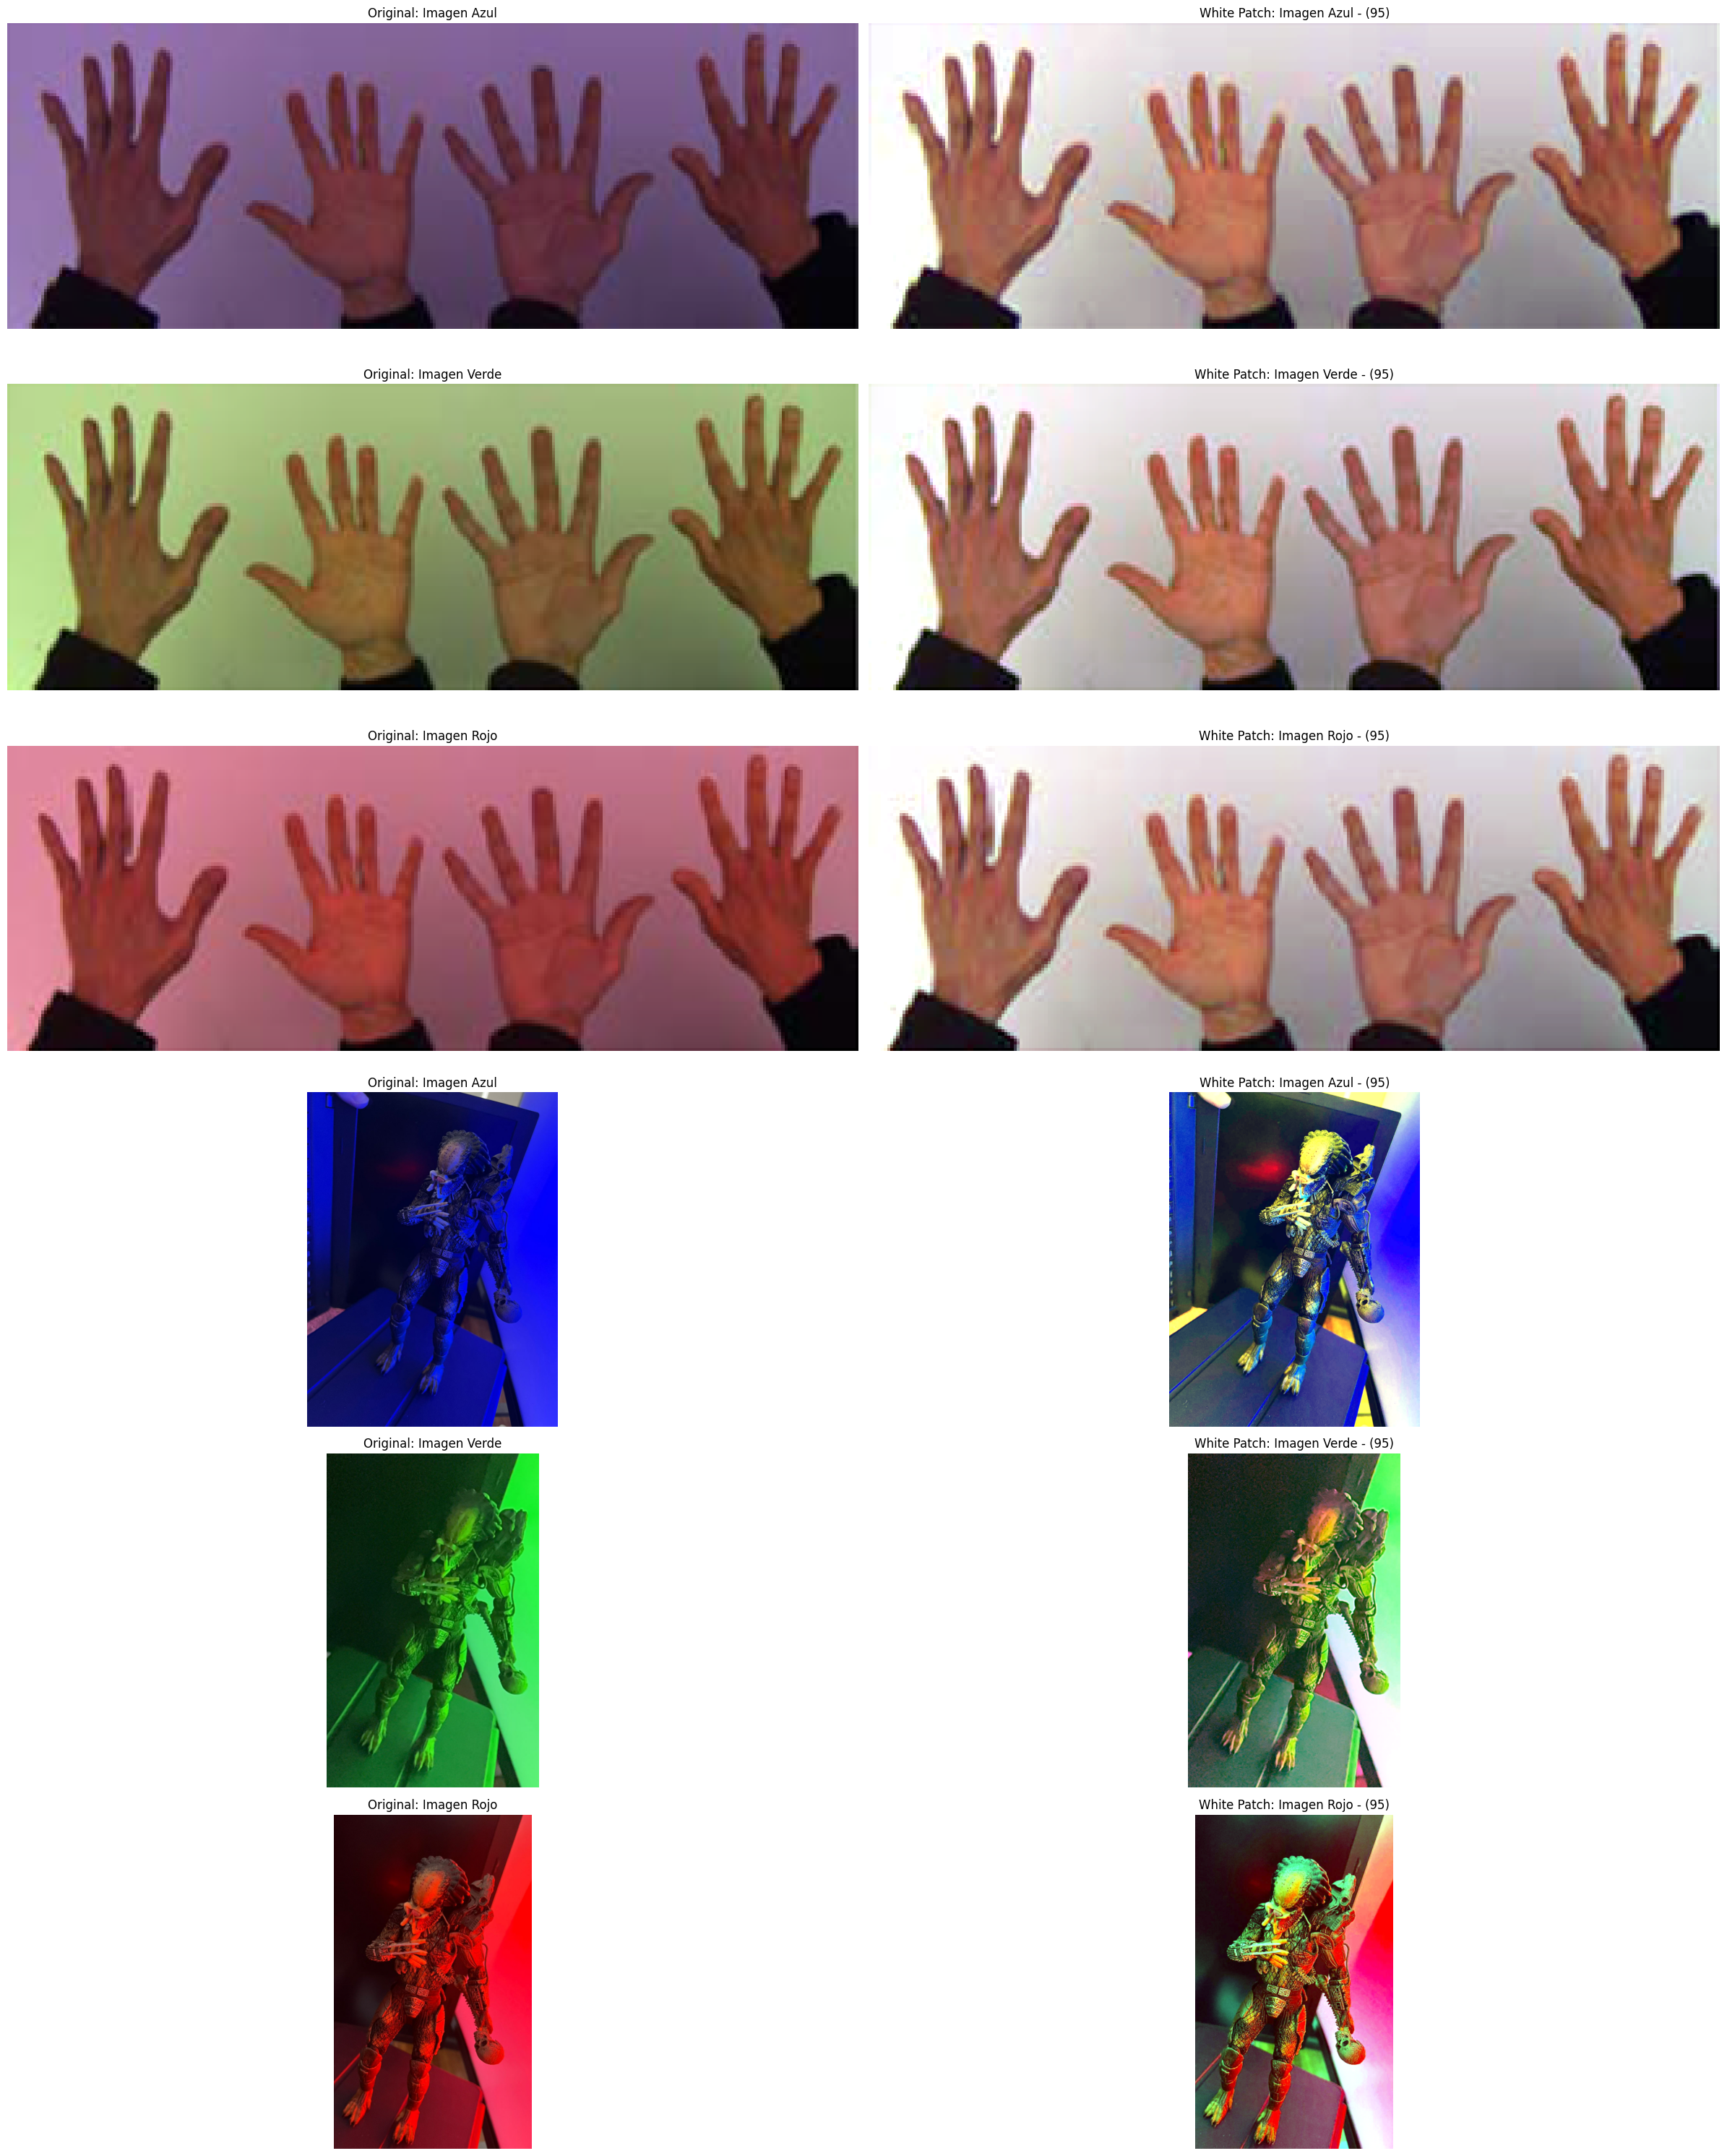

In [12]:
# Definimos imagenes 
images = ['./white_patch/test_blue.png', './white_patch/test_green.png', './white_patch/test_red.png', './white_patch/wp_blue.jpg', './white_patch/wp_green.png', './white_patch/wp_red.png' ]
titles =  ['Imagen Azul', 'Imagen Verde', 'Imagen Rojo', 'Imagen Azul', 'Imagen Verde', 'Imagen Rojo', ]
percentil = 95

fig, axs = plt.subplots( len(images), 2, figsize=( 24, 30 ))

for i in range( len( images )):
    # Load images
    img_orig = cv.imread(images[i])
    img_percentil = percentil
    if img_orig is None: 
        print(f"Erorr: image { images[i]} not loaded")
        continue

    img_corr = apply_white_patch( img_orig, percentile = img_percentil )

    orig_rgb = cv.cvtColor(img_orig, cv.COLOR_BGR2RGB)
    corr_rgb = cv.cvtColor(img_corr, cv.COLOR_BGR2RGB)

    # Colum original
    axs[ i, 0].imshow( orig_rgb)
    axs[ i, 0].set_title(f"Original: { titles[i] }")
    axs[ i, 0].axis('off')

    # Colum Fixed
    axs[ i, 1].imshow( corr_rgb)
    axs[ i, 1].set_title(f"White Patch: { titles[i] } - ({ percentil })")
    axs[ i, 1].axis('off')

plt.tight_layout()
plt.show()


### Analisis

Imagenes con poca iluminación (subexpuesta) el algoritmo tiende a saturar y generar zonas mas blancas e iluminadas como en el ejemplo del alien, donde se puede ver que algunos pixeles llegan a 255. 
En cambio en las imagenes de la mano, donde no hay tanta variedad de luz, son colores mas contrastados, el algoritmo corrige bastante bien la imagen, unifica los blancos, los resalta pero no satura ninguna imagen. 


### Parte 2:
1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grisas y 
visualizarlas. 
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas 
entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección 
de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

In [2]:
#Packetes utilizados
%matplotlib inline
# %matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

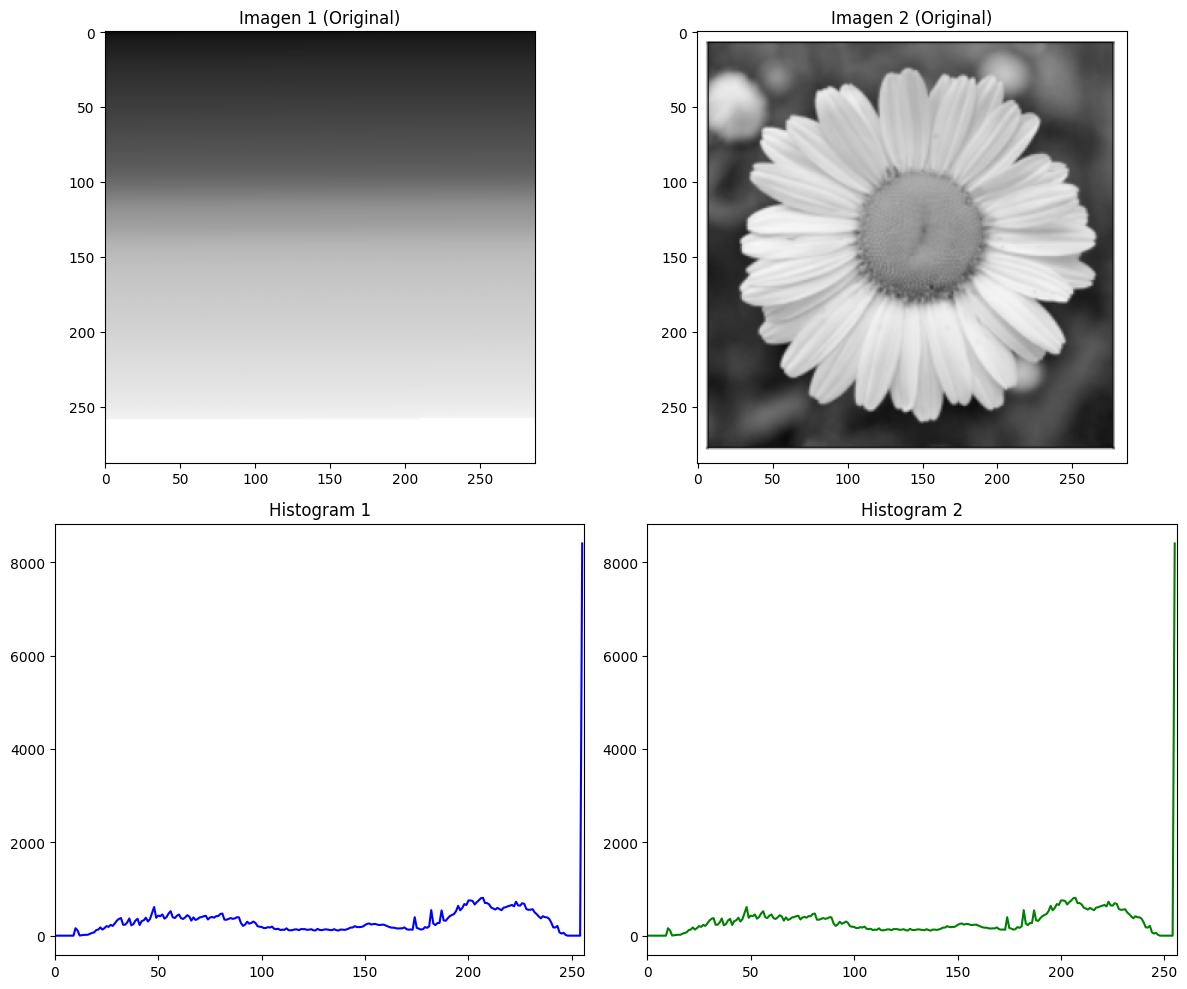

In [8]:
# 1 - Load images with OpenCV
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

if img1 is None or img2 is None: 
    print("Could not be read images")
    exit()

# show first image
cv.imshow("Display image 1", img1)

# show second images
cv.imshow("Display image 2", img2)

# Wait until press any key
# cv.waitKey(0) 

# Destoy the windows after rendered.
# cv.destroyAllWindows()

# 2 - Histograms 
fig = plt.figure(figsize=(12, 10))

# << --- COLUMN 1: img1  --- >>
# img1
ax1 = plt.subplot(221)
ax1.imshow(img1, cmap='gray', vmin=0, vmax=255)
ax1.set_title('Imagen 1 (Original)')

# Histogram
hist1, bins1 = np.histogram(img1.ravel(), 256, [0, 256])
ax3 = plt.subplot(223)
ax3.plot(hist1, color='blue')
ax3.set_title('Histogram 1')
ax3.set_xlim([0, 256]) 

# << --- COLUMN 2: img2--- >>
# Imagen
ax2 = plt.subplot(222)
ax2.imshow(img2, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Imagen 2 (Original)')

# Histogram
hist2, bins2 = np.histogram(img2.ravel(), 256, [0, 256])
ax4 = plt.subplot(224)
ax4.plot(hist2, color='green')
ax4.set_title('Histogram 2')
ax4.set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Analisis

Se observa que los histogramas no son suficientes por sí solos como 'features' para tareas de clasificación de objetos.

Aunque son útiles para describir la exposición luminica, el contraste o la iluminación de las imagenes, fallan al distinguir entre si estructuras espaciales totalmente distintas pero con distribuciones de intensidad similares.

Posiblemene pueda generar una alta tasa de falsos positivos en un modelo de clasificacion, ya que el histograma no difiere entre un degrade y una forma.